In [133]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [134]:
df = pd.read_csv(r"C:\allcoding\customer_data.csv", sep="\t")

In [135]:
df.shape

(2240, 29)

In [136]:
df.info

<bound method DataFrame.info of          ID  Year_Birth   Education Marital_Status   Income  Kidhome  \
0      5524        1957  Graduation         Single  58138.0        0   
1      2174        1954  Graduation         Single  46344.0        1   
2      4141        1965  Graduation       Together  71613.0        0   
3      6182        1984  Graduation       Together  26646.0        1   
4      5324        1981         PhD        Married  58293.0        1   
...     ...         ...         ...            ...      ...      ...   
2235  10870        1967  Graduation        Married  61223.0        0   
2236   4001        1946         PhD       Together  64014.0        2   
2237   7270        1981  Graduation       Divorced  56981.0        0   
2238   8235        1956      Master       Together  69245.0        0   
2239   9405        1954         PhD        Married  52869.0        1   

      Teenhome Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  \
0            0  04-09-2012    

In [137]:
df.head

<bound method NDFrame.head of          ID  Year_Birth   Education Marital_Status   Income  Kidhome  \
0      5524        1957  Graduation         Single  58138.0        0   
1      2174        1954  Graduation         Single  46344.0        1   
2      4141        1965  Graduation       Together  71613.0        0   
3      6182        1984  Graduation       Together  26646.0        1   
4      5324        1981         PhD        Married  58293.0        1   
...     ...         ...         ...            ...      ...      ...   
2235  10870        1967  Graduation        Married  61223.0        0   
2236   4001        1946         PhD       Together  64014.0        2   
2237   7270        1981  Graduation       Divorced  56981.0        0   
2238   8235        1956      Master       Together  69245.0        0   
2239   9405        1954         PhD        Married  52869.0        1   

      Teenhome Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  \
0            0  04-09-2012      

In [138]:
df.describe

<bound method NDFrame.describe of          ID  Year_Birth   Education Marital_Status   Income  Kidhome  \
0      5524        1957  Graduation         Single  58138.0        0   
1      2174        1954  Graduation         Single  46344.0        1   
2      4141        1965  Graduation       Together  71613.0        0   
3      6182        1984  Graduation       Together  26646.0        1   
4      5324        1981         PhD        Married  58293.0        1   
...     ...         ...         ...            ...      ...      ...   
2235  10870        1967  Graduation        Married  61223.0        0   
2236   4001        1946         PhD       Together  64014.0        2   
2237   7270        1981  Graduation       Divorced  56981.0        0   
2238   8235        1956      Master       Together  69245.0        0   
2239   9405        1954         PhD        Married  52869.0        1   

      Teenhome Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  \
0            0  04-09-2012  

In [139]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [140]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [141]:
df.fillna(df.median(numeric_only=True), inplace=True)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [104]:
df.duplicated().sum()

np.int64(0)

In [106]:
print(df.columns.tolist())

['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


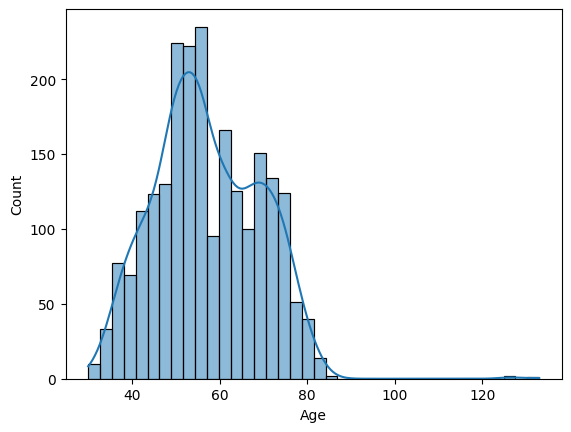

In [109]:
sns.histplot(df["Age"], kde=True)
plt.show()

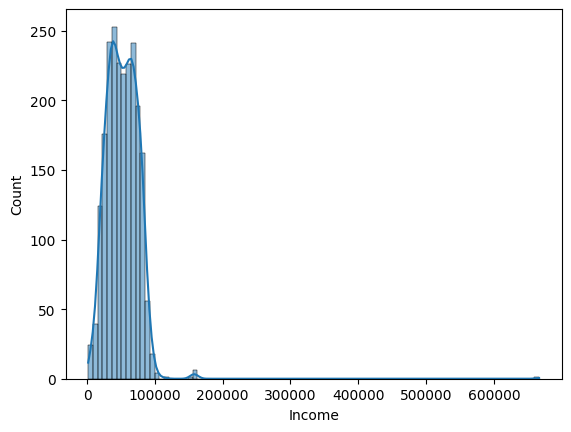

In [110]:
sns.histplot(df["Income"], kde=True)
plt.show()

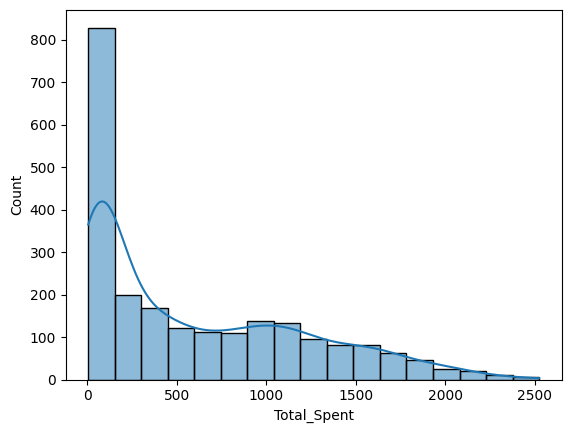

In [111]:
sns.histplot(df["Total_Spent"], kde=True)
plt.show()

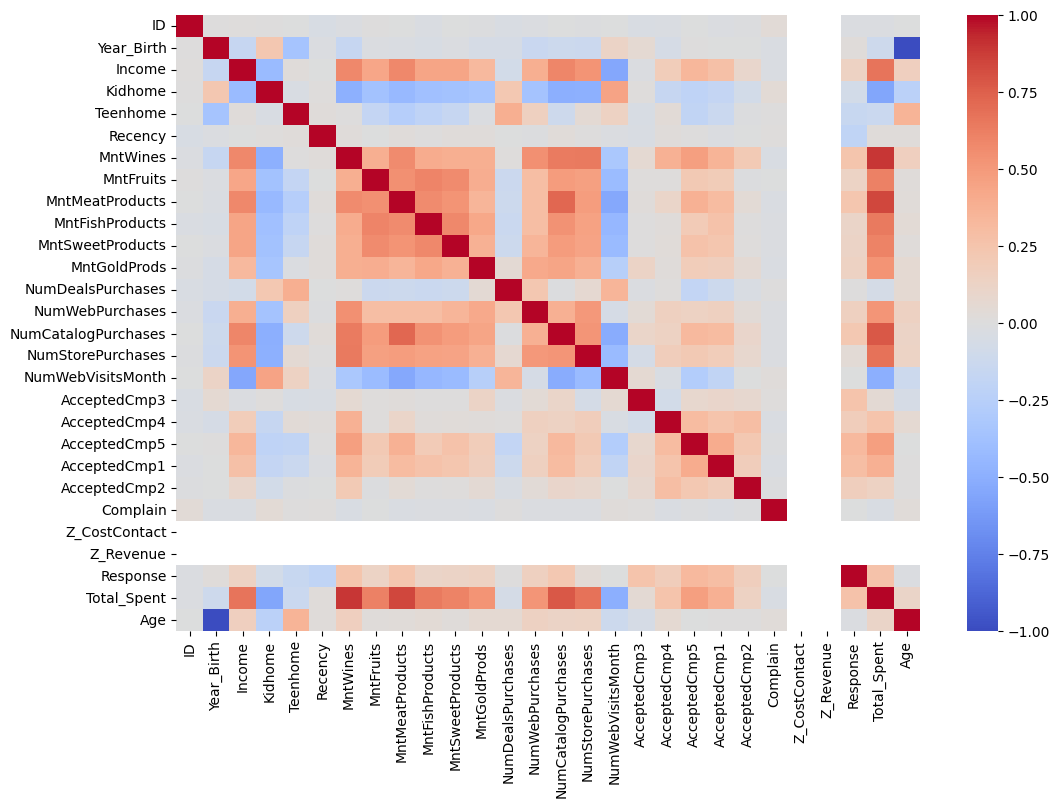

In [112]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm"
)

plt.show()

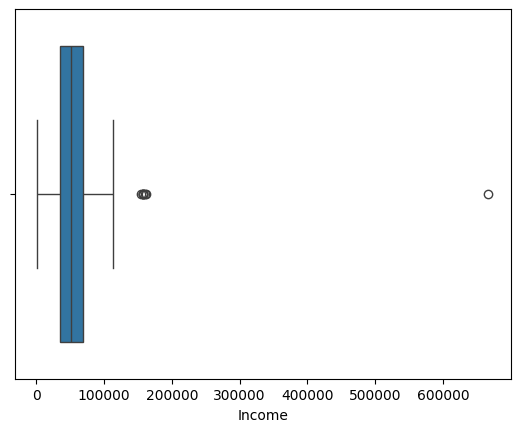

In [113]:
sns.boxplot(x=df['Income'])
plt.show()

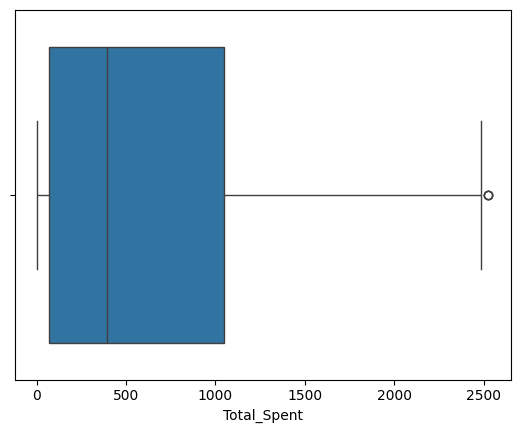

In [114]:
sns.boxplot(x=df['Total_Spent'])
plt.show()

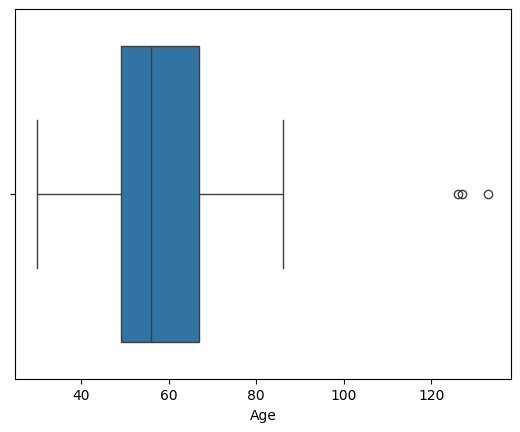

In [115]:
sns.boxplot(x=df['Age'])
plt.show()

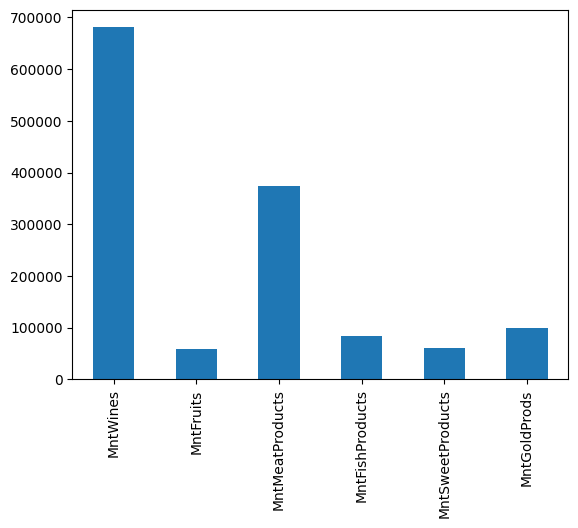

In [116]:
spending_cols = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

df[spending_cols].sum().plot(
    kind='bar'
)

plt.show()

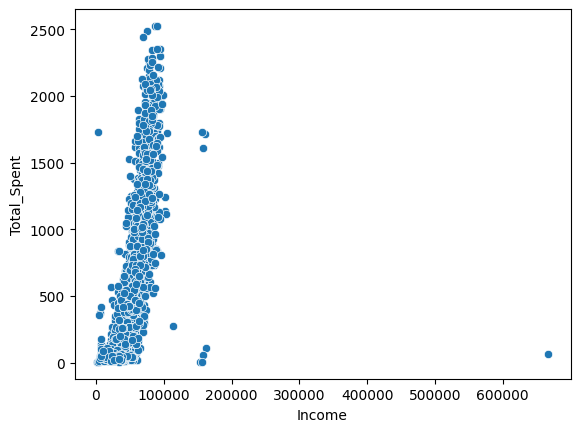

In [117]:
sns.scatterplot(
    x='Income',
    y='Total_Spent',
    data=df
)

plt.show()

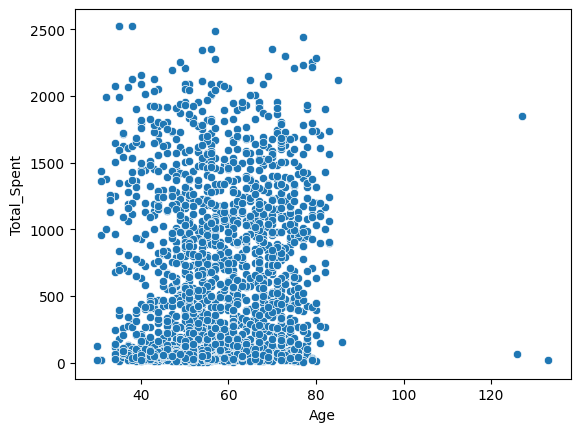

In [118]:
sns.scatterplot(
    x='Age',
    y='Total_Spent',
    data=df
)

plt.show()

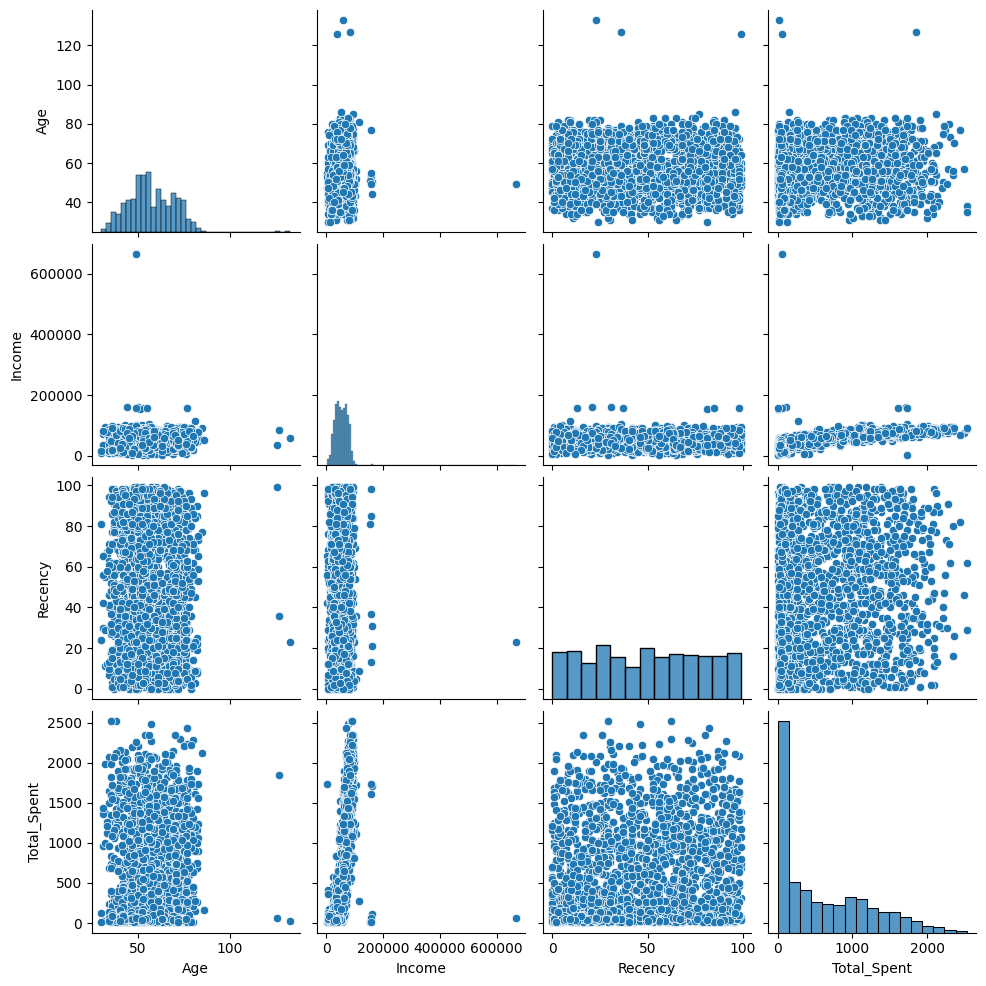

In [119]:
cols = [
    'Age',
    'Income',
    'Recency',
    'Total_Spent'
]

sns.pairplot(df[cols])

plt.show()

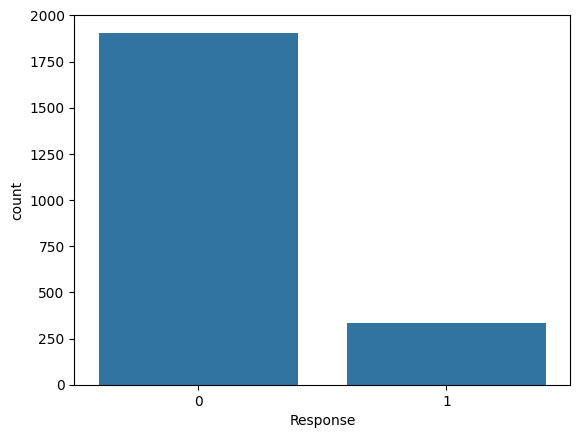

In [120]:
sns.countplot(
    x='Response',
    data=df
)

plt.show()

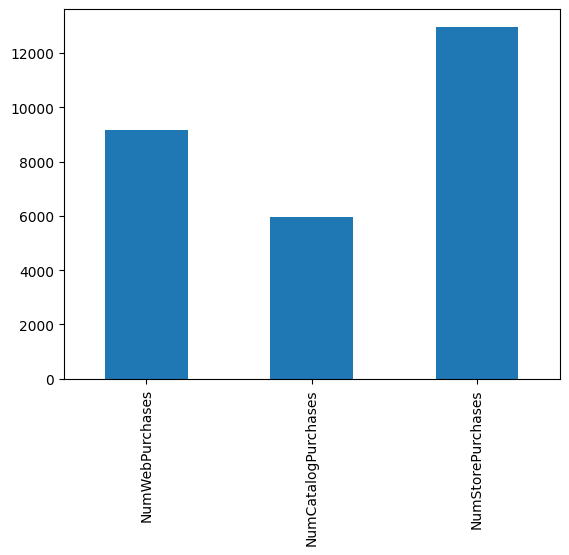

In [121]:
purchase_cols = [
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases'
]

df[purchase_cols].sum().plot(
    kind='bar'
)

plt.show()

In [142]:
df.fillna(df.median(numeric_only=True), inplace=True)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [144]:
df.drop(["ID","Dt_Customer"], axis=1, inplace=True)

In [146]:
df = pd.get_dummies(
    df,
    columns=['Education', 'Marital_Status'],
    drop_first=True
)

In [147]:
df.shape

(2240, 36)

In [148]:
df.select_dtypes(include='object').columns

Index([], dtype='str')

In [149]:
X = df.copy()

In [152]:
#Standardize Data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled.shape

(2240, 36)

In [153]:
#PCA Variance Analysis
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

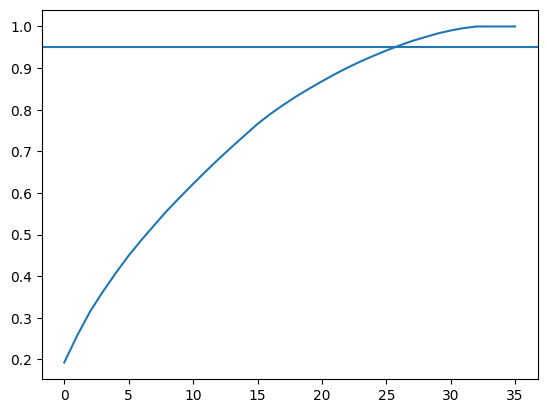

In [154]:
cum_var = np.cumsum(
    pca.explained_variance_ratio_
)

plt.plot(cum_var)
plt.axhline(y=0.95)
plt.show()

In [157]:
pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_scaled)


In [158]:
X_pca.shape

(2240, 27)

In [159]:
# ELBOW method
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_pca)

    wcss.append(kmeans.inertia_)

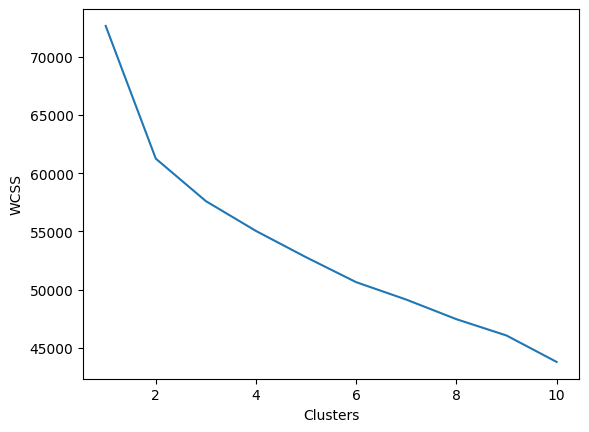

In [160]:
plt.plot(range(1,11), wcss)
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

In [162]:
#Silhouette Score
scores = []

for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = km.fit_predict(X_pca)

    score = silhouette_score(
        X_pca,
        labels
    )

    scores.append(score)

    print(k, score)

2 0.1875224107544816
3 0.12607264567801615
4 0.1262484186465577
5 0.12414098119560774
6 0.13107339784305502
7 0.07610584284958384
8 0.12449475266731871
9 0.1292074445057813
10 0.1253585074258997


In [164]:
best_k = 4
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42
)

clusters = kmeans.fit_predict(X_pca)

In [165]:
df["Cluster"] = clusters

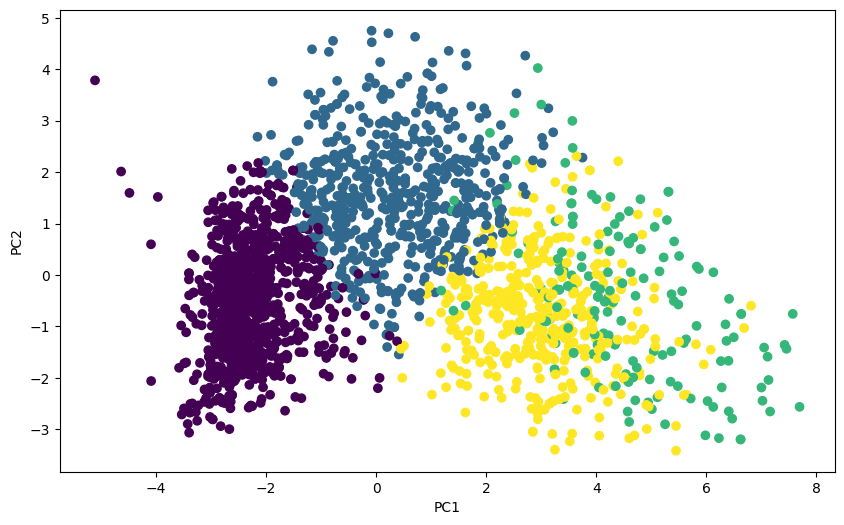

In [166]:
#Cluster Visualization
plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["Cluster"]
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [167]:
# cluster analysis 
cluster_summary = (
    df.groupby("Cluster")
      .mean(numeric_only=True)
)

cluster_summary

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
Cluster,,,,,,,,,,,,,,,,,,,,,
0,1971.926514,34474.199106,0.815293,0.429990,49.257200,38.291956,4.897716,22.614697,6.983118,4.987090,...,0.497517,0.155909,0.182721,0.001986,0.095333,0.386296,0.239325,0.253227,0.023833,0.000000
1,1964.082524,57270.317961,0.231392,0.932039,48.519417,443.440129,19.839806,127.037217,27.037217,20.111650,...,0.443366,0.213592,0.289644,0.001618,0.127832,0.406149,0.152104,0.270227,0.038835,0.003236
2,1969.389535,81537.500000,0.052326,0.133721,49.930233,876.098837,56.168605,467.145349,76.796512,65.168605,...,0.523256,0.162791,0.244186,0.000000,0.081395,0.424419,0.186047,0.255814,0.046512,0.000000
3,1968.074492,74221.309255,0.049661,0.230248,49.277652,491.018059,72.376975,434.169300,106.336343,72.146727,...,0.591422,0.119639,0.182844,0.000000,0.097065,0.340858,0.255079,0.257336,0.047404,0.000000


In [170]:
print(df.columns.tolist())
cluster_summary.columns

['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Education_Basic', 'Education_Graduation', 'Education_Master', 'Education_PhD', 'Marital_Status_Alone', 'Marital_Status_Divorced', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Widow', 'Marital_Status_YOLO', 'Cluster']


Index(['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Education_Basic', 'Education_Graduation', 'Education_Master',
       'Education_PhD', 'Marital_Status_Alone', 'Marital_Status_Divorced',
       'Marital_Status_Married', 'Marital_Status_Single',
       'Marital_Status_Together', 'Marital_Status_Widow',
       'Marital_Status_YOLO'],
      dtype='str')

In [171]:
df["Age"] = 2026 - df["Year_Birth"]

df["Total_Spent"] = (
    df["MntWines"]
    + df["MntFruits"]
    + df["MntMeatProducts"]
    + df["MntFishProducts"]
    + df["MntSweetProducts"]
    + df["MntGoldProds"]
)

In [172]:
print("Age" in df.columns)
print("Total_Spent" in df.columns)

True
True


In [173]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)

cluster_summary[['Income', 'Age', 'Total_Spent']]

,Income,Age,Total_Spent
Cluster,,,
0,34474.199106,54.073486,93.130089
1,57270.317961,61.917476,694.488673
2,81537.500000,56.610465,1618.709302
3,74221.309255,57.925508,1254.162528


# Customer Personas

## Cluster 0 – Budget-Conscious Customers

### Characteristics
- Average Income: ₹34,474
- Average Age: 54 years
- Average Total Spending: 93

### Persona Description
These customers have the lowest income and spending levels among all clusters. They are highly price-sensitive and generally purchase only essential products.

### Business Strategy
- Offer discounts and coupons
- Promote budget-friendly products
- Provide seasonal sales offers
- Encourage repeat purchases through reward programs

---

## Cluster 1 – Moderate Value Customers

### Characteristics
- Average Income: ₹57,270
- Average Age: 62 years
- Average Total Spending: 694

### Persona Description
These customers have moderate purchasing power and spending behavior. They contribute stable revenue and are likely to respond positively to value-based offers.

### Business Strategy
- Introduce loyalty programs
- Offer bundled products
- Provide membership benefits
- Send personalized promotional offers

---

## Cluster 2 – Premium Customers

### Characteristics
- Average Income: ₹81,538
- Average Age: 57 years
- Average Total Spending: 1,619

### Persona Description
These are the highest-value customers with the greatest purchasing power and spending levels. They contribute significantly to business revenue.

### Business Strategy
- Provide VIP memberships
- Offer exclusive products and services
- Deliver personalized recommendations
- Ensure premium customer support

---

## Cluster 3 – High-Value Customers

### Characteristics
- Average Income: ₹74,221
- Average Age: 58 years
- Average Total Spending: 1,254

### Persona Description
These customers have high income and strong spending behavior. They represent a valuable customer segment with significant growth potential.

### Business Strategy
- Implement cross-selling campaigns
- Promote premium products
- Offer personalized marketing campaigns
- Encourage higher spending through exclusive deals

# Business Recommendations

## Recommendation 1
Focus customer retention efforts on Cluster 2 (Premium Customers), as they generate the highest revenue.

## Recommendation 2
Design personalized marketing campaigns for Cluster 3 (High-Value Customers) to increase spending and engagement.

## Recommendation 3
Provide loyalty rewards and membership programs for Cluster 1 (Moderate Value Customers) to improve retention.

## Recommendation 4
Use discounts, coupons, and promotional offers for Cluster 0 (Budget-Conscious Customers) to encourage purchases.

## Recommendation 5
Adopt customer segmentation-based marketing instead of a single strategy for all customers.

## Recommendation 6
Allocate a larger marketing budget toward Clusters 2 and 3 because they contribute the most value to the business.

## Recommendation 7
Utilize customer behavior insights from clustering to improve targeting, customer satisfaction, and overall profitability.

# Conclusion

This project successfully applied Principal Component Analysis (PCA) and K-Means Clustering to perform customer segmentation on retail customer data.

The dataset was cleaned, standardized, and transformed using PCA, reducing dimensionality while retaining approximately 95% of the original information. The optimal number of clusters was determined using the Elbow Method and Silhouette Score.

The final K-Means model identified four distinct customer segments:

- Cluster 0: Budget-Conscious Customers
- Cluster 1: Moderate Value Customers
- Cluster 2: Premium Customers
- Cluster 3: High-Value Customers

Cluster 2 emerged as the most profitable customer segment, having the highest income and spending levels. Cluster 3 also demonstrated strong purchasing behavior and significant business value.

The customer personas developed from the clustering results provide actionable insights for targeted marketing, customer retention, and revenue optimization.

Overall, this project demonstrates how unsupervised learning techniques can uncover hidden patterns in customer behavior and support data-driven business decision-making.